In [108]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [109]:
print("All Libaries loaded")

All Libaries loaded


In [110]:
url = "http://api.worldbank.org/v2/country/all/indicator/FX.OWN.TOTL.ZS?date=2021&format=json&per_page=300"
response = requests.get(url)


In [111]:
print(response.status_code)

200


In [112]:
data = response.json()


In [113]:
print(type(data))

print(len(data))

<class 'list'>
2


In [114]:
print(data[0])


{'page': 1, 'pages': 1, 'per_page': 300, 'total': 266, 'sourceid': '2', 'lastupdated': '2026-04-08'}


In [115]:
print(data[1][0])

{'indicator': {'id': 'FX.OWN.TOTL.ZS', 'value': 'Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+)'}, 'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'}, 'countryiso3code': 'AFE', 'date': '2021', 'value': None, 'unit': '', 'obs_status': '', 'decimal': 2}


In [116]:
records  = data[1]
real_data = [entry for entry in records if entry['value'] is not None]
print(f"Total entries: {len(records)}")
print(f"Entries with actual data: {len(real_data)}")

Total entries: 266
Entries with actual data: 144


In [117]:
df_wb = pd.DataFrame([
    {
        'country': entry['country']['value'],
        'country_code': entry['countryiso3code'],
        'year': entry['date'],
        'account_ownership': entry['value']
        }
    for entry in real_data

]
)
print(df_wb.head())

                                       country country_code  year  \
0                                   Arab World          ARB  2021   
1                          East Asia & Pacific          EAS  2021   
2  East Asia & Pacific (excluding high income)          EAP  2021   
3                                    Euro area          EMU  2021   
4                        Europe & Central Asia          ECS  2021   

   account_ownership  
0          40.210000  
1          82.850000  
2          79.701061  
3          98.510000  
4          89.570000  


In [118]:
df_wb.describe()

,account_ownership
count,144.000000
mean,70.205597
std,24.602815
min,5.831407
25%,49.577413
50%,73.425181
75%,94.897254
max,100.000000


In [119]:
df_wb.sort_values('account_ownership').head(10)


,country,country_code,year,account_ownership
122,South Sudan,SSD,2021,5.831407
22,Afghanistan,AFG,2021,9.653822
70,Iraq,IRQ,2021,18.565282
84,Lebanon,LBN,2021,20.703098
105,Pakistan,PAK,2021,20.980631
101,Nicaragua,NIC,2021,26.032803
52,"Egypt, Arab Rep.",EGY,2021,27.444006
117,Sierra Leone,SLE,2021,28.846604
62,Guinea,GIN,2021,30.440336
37,Cambodia,KHM,2021,33.394992


In [120]:
df_wb.sort_values('account_ownership', ascending=False).head(5)



,country,country_code,year,account_ownership
49,Denmark,DNK,2021,100.000000
66,Iceland,ISL,2021,100.000000
59,Germany,DEU,2021,99.976594
28,Austria,AUT,2021,99.950717
136,United Kingdom,GBR,2021,99.763274


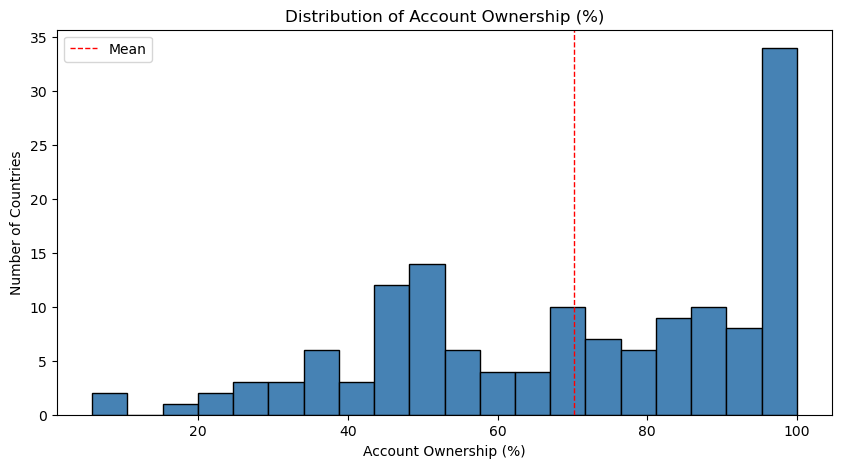

In [121]:
plt.figure(figsize=(10, 5))
plt.hist(df_wb['account_ownership'], bins=20, edgecolor='black',color='steelblue')
plt.title('Distribution of Account Ownership (%)')
plt.xlabel('Account Ownership (%)')
plt.ylabel('Number of Countries')
plt.axvline(df_wb['account_ownership'].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.legend()
plt.show()



In [122]:
print(df_wb[df_wb['account_ownership'] > 95].shape)

(34, 4)


## GDP Per Capita from 2000 to 2021


In [163]:
url_GDP_PC = "http://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.CD?date=2000:2021&format=json&per_page=6000"
response_gdp_pc = requests.get(url_GDP_PC)


In [164]:
print(response_gdp_pc.status_code)
data_gdp_pc = response_gdp_pc.json()

200


In [165]:
print(type(data_gdp_pc))
print(len(data_gdp_pc))

<class 'list'>
2


In [166]:
print(data_gdp_pc[1])

[{'indicator': {'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per capita (current US$)'}, 'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'}, 'countryiso3code': 'AFE', 'date': '2021', 'value': 1562.41617477738, 'unit': '', 'obs_status': '', 'decimal': 1}, {'indicator': {'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per capita (current US$)'}, 'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'}, 'countryiso3code': 'AFE', 'date': '2020', 'value': 1351.59166910879, 'unit': '', 'obs_status': '', 'decimal': 1}, {'indicator': {'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per capita (current US$)'}, 'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'}, 'countryiso3code': 'AFE', 'date': '2019', 'value': 1507.08559963484, 'unit': '', 'obs_status': '', 'decimal': 1}, {'indicator': {'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per capita (current US$)'}, 'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'}, 'countryiso3code': 'AFE', 'date': '2018', 'value': 1552.07372194919, 'uni

In [167]:
records_gdp_pc  = data_gdp_pc[1]
real_data_gdp_pc = [entry for entry in records_gdp_pc if entry['value'] is not None]
print(f"Total Entries for GDP  per Capita : {len(records_gdp_pc)}")
print(f"Entries with Actual data: {len(real_data_gdp_pc)}")

Total Entries for GDP  per Capita : 5852
Entries with Actual data: 5685


In [168]:
df_gdp_pc = pd.DataFrame([
    {
        'country': entry['country']['value'],
        'country_code' : entry['countryiso3code'],
        'year': entry['date'],
        'gdp_per_capita': entry['value']
    }
    for entry in real_data_gdp_pc
])

In [169]:
print(df_gdp_pc.head())

                       country country_code  year  gdp_per_capita
0  Africa Eastern and Southern          AFE  2021     1562.416175
1  Africa Eastern and Southern          AFE  2020     1351.591669
2  Africa Eastern and Southern          AFE  2019     1507.085600
3  Africa Eastern and Southern          AFE  2018     1552.073722
4  Africa Eastern and Southern          AFE  2017     1528.104224


In [170]:
df_gdp_pc.describe()

,gdp_per_capita
count,5685.000000
mean,14267.326864
std,22530.897876
min,109.593814
25%,1482.815663
50%,4788.833423
75%,17803.947177
max,223823.363960


In [171]:
df_gdp_pc.sort_values('gdp_per_capita').head(10)

,country,country_code,year,gdp_per_capita
2441,Ethiopia,ETH,2002,109.593814
1732,Burundi,BDI,2003,111.406683
2440,Ethiopia,ETH,2003,116.800491
2442,Ethiopia,ETH,2001,118.457204
1733,Burundi,BDI,2002,120.952309
2443,Ethiopia,ETH,2000,122.269203
1731,Burundi,BDI,2004,125.194965
1734,Burundi,BDI,2001,132.159555
2439,Ethiopia,ETH,2004,133.169813
1735,Burundi,BDI,2000,134.537862


In [172]:
df_gdp_pc.sort_values('year').head(5)

,country,country_code,year,gdp_per_capita
5684,Zimbabwe,ZWE,2000,562.833757
901,Small states,SST,2000,4846.982126
3511,Lithuania,LTU,2000,3300.636349
2509,Finland,FIN,2000,24335.922508
4986,St. Vincent and the Grenadines,VCT,2000,3768.955366


In [173]:
df_merged = df_gdp_pc.merge(df_gdp_pc, on='country_code')
print(df_merged.shape)
df_merged.head()

(129969, 7)


,country_x,country_code,year_x,gdp_per_capita_x,country_y,year_y,gdp_per_capita_y
0,Africa Eastern and Southern,AFE,2021,1562.416175,Africa Eastern and Southern,2021,1562.416175
1,Africa Eastern and Southern,AFE,2021,1562.416175,Africa Eastern and Southern,2020,1351.591669
2,Africa Eastern and Southern,AFE,2021,1562.416175,Africa Eastern and Southern,2019,1507.085600
3,Africa Eastern and Southern,AFE,2021,1562.416175,Africa Eastern and Southern,2018,1552.073722
4,Africa Eastern and Southern,AFE,2021,1562.416175,Africa Eastern and Southern,2017,1528.104224


In [175]:
print(df_gdp_pc['country_code'].nunique())


259


In [176]:
df_gdp_2021 = df_gdp_pc[df_gdp_pc['year'] == '2021']
print(df_gdp_2021.shape)

(258, 4)


In [178]:
df_merged = df_wb.merge(df_gdp_2021, on='country_code')
print(df_merged.shape)
df_merged.head()


(155, 7)


,country_x,country_code,year_x,account_ownership,country_y,year_y,gdp_per_capita
0,Arab World,ARB,2021,40.210000,Arab World,2021,6697.414985
1,East Asia & Pacific,EAS,2021,82.850000,East Asia & Pacific,2021,13336.484167
2,East Asia & Pacific (excluding high income),EAP,2021,79.701061,East Asia & Pacific (excluding high income),2021,9974.578297
3,Euro area,EMU,2021,98.510000,Euro area,2021,42984.569741
4,Europe & Central Asia,ECS,2021,89.570000,Europe & Central Asia,2021,27664.891408


In [179]:
df_merged = df_merged.drop(columns=['country_y', 'year_y'])
df_merged = df_merged.rename(columns={'country_x': 'country', 'year_x': 'year'})
print(df_merged.columns)

Index(['country', 'country_code', 'year', 'account_ownership',
       'gdp_per_capita'],
      dtype='object')


In [180]:
df_world_gdp = df_gdp_pc.groupby('year')['gdp_per_capita'].mean()
print(df_world_gdp)

year
2000     7563.714187
2001     7571.516244
2002     8175.551954
2003     9397.095856
2004    10683.627339
2005    11581.680478
2006    12941.878955
2007    14721.778120
2008    15787.123120
2009    14310.259616
2010    15046.841615
2011    16566.449702
2012    16450.714381
2013    17007.388694
2014    17312.060995
2015    15660.924513
2016    15783.784841
2017    16592.499881
2018    17573.925150
2019    17537.480522
2020    16283.153813
2021    18803.437185
Name: gdp_per_capita, dtype: float64


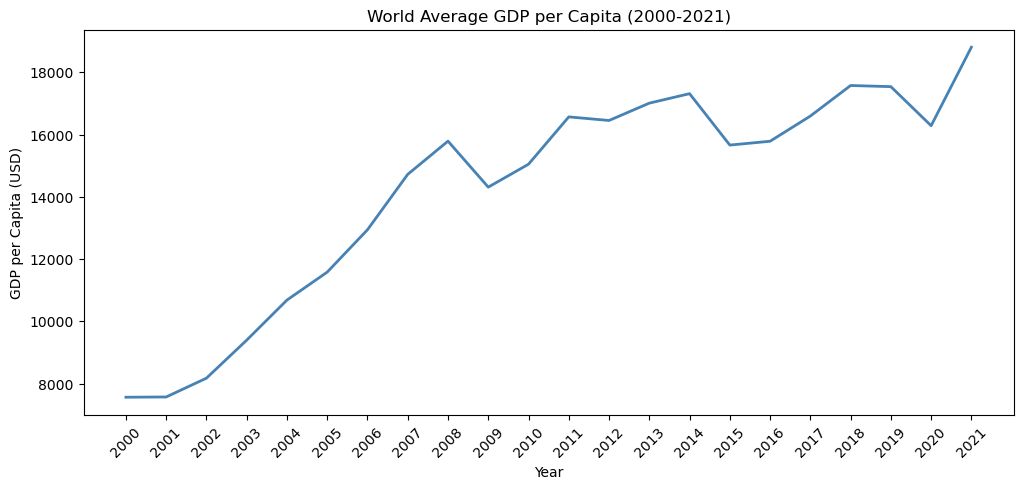

In [181]:
plt.figure(figsize=(12, 5))
plt.plot(df_world_gdp.index, df_world_gdp.values, color='steelblue', linewidth=2)
plt.title('World Average GDP per Capita (2000-2021)')
plt.xlabel('Year')
plt.ylabel('GDP per Capita (USD)')
plt.xticks(rotation=45)
plt.show()

Access to electricity [AtE] (% of population)

In [ ]:
url_ATE = "http://api.worldbank.org/v2/country/all/indicator/EG.ELC.ACCS.ZS?date=2021&format=json&per_page=6000"
response_ate = requests.get(url_ATE)

In [185]:
data_ate = response_ate.json()

In [195]:
print(type(data_ate))
print(len(data_ate))
print(data_ate[1])

<class 'list'>
2
[{'indicator': {'id': 'EG.ELC.ACCS.ZS', 'value': 'Access to electricity (% of population)'}, 'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'}, 'countryiso3code': 'AFE', 'date': '2021', 'value': 48.1272110400485, 'unit': '', 'obs_status': '', 'decimal': 1}, {'indicator': {'id': 'EG.ELC.ACCS.ZS', 'value': 'Access to electricity (% of population)'}, 'country': {'id': 'ZI', 'value': 'Africa Western and Central'}, 'countryiso3code': 'AFW', 'date': '2021', 'value': 54.368598708444, 'unit': '', 'obs_status': '', 'decimal': 1}, {'indicator': {'id': 'EG.ELC.ACCS.ZS', 'value': 'Access to electricity (% of population)'}, 'country': {'id': '1A', 'value': 'Arab World'}, 'countryiso3code': 'ARB', 'date': '2021', 'value': 90.4340947732985, 'unit': '', 'obs_status': '', 'decimal': 1}, {'indicator': {'id': 'EG.ELC.ACCS.ZS', 'value': 'Access to electricity (% of population)'}, 'country': {'id': 'S3', 'value': 'Caribbean small states'}, 'countryiso3code': 'CSS', 'date': '2

In [202]:
records_ate  = data_ate[1]
real_data_ate = [entry for entry in records_ate if entry['value'] is not None]
print(f"Total Entries for Access to Electricity: {len(records_ate)}")
print(f"Entries with Valid Data: {len(real_data_ate)}")

Total Entries for Access to Electricity: 266
Entries with Valid Data: 263


In [203]:
df_ate = pd.DataFrame([
    {
        'country': entry['country']['value'],
        'country_code': entry['countryiso3code'],
        'year': entry['date'],
        'access_to_electricity': entry['value']
    }
    for entry in real_data_ate
])
print(df_ate.head())

                          country country_code  year  access_to_electricity
0     Africa Eastern and Southern          AFE  2021              48.127211
1      Africa Western and Central          AFW  2021              54.368599
2                      Arab World          ARB  2021              90.434095
3          Caribbean small states          CSS  2021              98.174699
4  Central Europe and the Baltics          CEB  2021              99.987012


In [204]:
df_ate.describe()

,access_to_electricity
count,263.000000
mean,86.855188
std,22.889985
min,7.700000
25%,85.985409
50%,99.976387
75%,100.000000
max,100.000000


In [205]:
# Merge Access to Electricity with GDP per Capita for 2021

df_gdp_pc2021 = df_gdp_pc[df_gdp_pc['year'] == '2021']
df_gdp_pc2021.head()

,country,country_code,year,gdp_per_capita
0,Africa Eastern and Southern,AFE,2021,1562.416175
22,Africa Western and Central,AFW,2021,2112.794076
44,Arab World,ARB,2021,6697.414985
66,Caribbean small states,CSS,2021,13995.269492
88,Central Europe and the Baltics,CEB,2021,19223.927403


In [207]:
print(len(df_gdp_pc2021))
print(len(df_ate))

258
263
